Saving netflix_titles.csv to netflix_titles.csv
    show_id     type                                    title  \
0  81145628    Movie  Norm of the North: King Sized Adventure   
1  80117401    Movie               Jandino: Whatever it Takes   
2  70234439  TV Show                       Transformers Prime   
3  80058654  TV Show         Transformers: Robots in Disguise   
4  80125979    Movie                             #realityhigh   

                   director  \
0  Richard Finn, Tim Maltby   
1                       NaN   
2                       NaN   
3                       NaN   
4          Fernando Lebrija   

                                                cast  \
0  Alan Marriott, Andrew Toth, Brian Dobson, Cole...   
1                                   Jandino Asporaat   
2  Peter Cullen, Sumalee Montano, Frank Welker, J...   
3  Will Friedle, Darren Criss, Constance Zimmer, ...   
4  Nesta Cooper, Kate Walsh, John Michael Higgins...   

                                    c

/tmp/ipykernel_2801/1776691779.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['date_added'] = pd.to_datetime(
/tmp/ipykernel_2801/1776691779.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['year_added'] = df_clean['date_added'].dt.year
/tmp/ipykernel_2801/1776691779.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

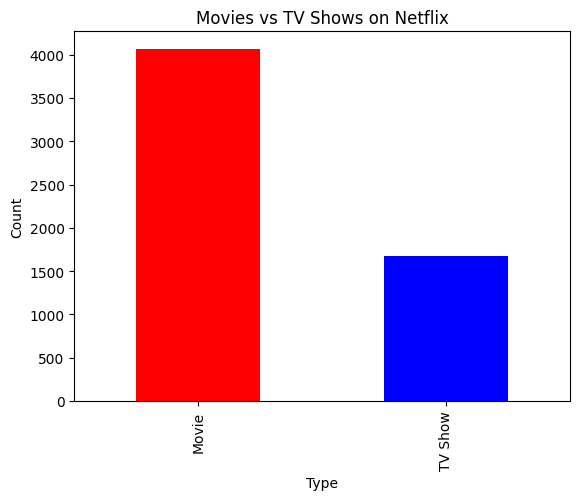

country
United States     2023
India              777
United Kingdom     347
Japan              174
Canada             141
Name: count, dtype: int64


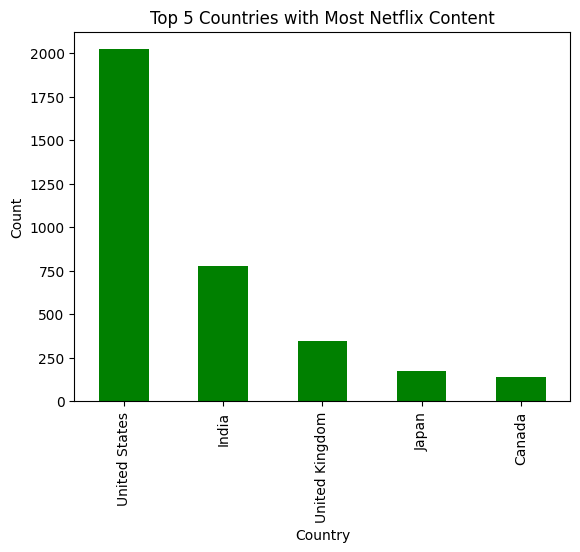

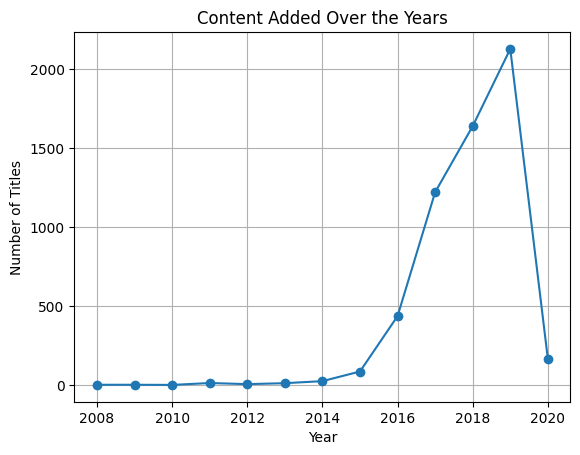

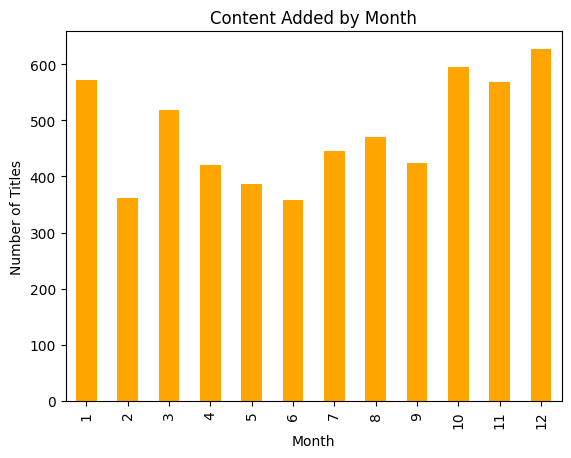

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Upload the CSV file
uploaded = files.upload()   # upload netflix_titles.csv manually

# Load dataset
df = pd.read_csv("netflix_titles.csv")

# =========================
# BASIC DATA EXPLORATION
# =========================
print(df.head())
print("Shape of dataset:", df.shape)
print("Columns:", df.columns)
print(df.info())

# =========================
# DATA CLEANING
# =========================
print("\nShape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

# Remove rows with important missing values
df_clean = df.dropna(subset=['country', 'date_added', 'rating'])

# Remove extra spaces and convert date
df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'].astype(str).str.strip(),
    errors='coerce'
)

# Extract year and month
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month

print(f"\nRows after cleaning: {len(df_clean)}")
print("Duplicates:", df_clean.duplicated().sum())

# Remove duplicates if any
df_clean = df_clean.drop_duplicates()

# =========================
# MOVIES VS TV SHOWS
# =========================
print(df_clean['type'].value_counts())

df_clean['type'].value_counts().plot(
    kind='bar',
    color=['red', 'blue']
)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

# =========================
# TOP 5 COUNTRIES
# =========================
top_countries = df_clean['country'].value_counts().head(5)

print(top_countries)

top_countries.plot(kind='bar', color='green')

plt.title("Top 5 Countries with Most Netflix Content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

# =========================
# CONTENT ADDED OVER YEARS
# =========================
df_clean['year_added'].value_counts().sort_index().plot(
    kind='line',
    marker='o'
)

plt.title("Content Added Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

# =========================
# CONTENT ADDED BY MONTH
# =========================
df_clean['month_added'].value_counts().sort_index().plot(
    kind='bar',
    color='orange'
)

plt.title("Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")
plt.show()